### Colab Activity 21.5: Multiclass Classification with Keras

**Expected Time = 90 minutes**



This activity focuses on using `keras` to build a multi-class classification model using the wine dataset from the earlier module. You will use the version of the dataset loaded with scikitlearn.  Below, the data is loaded and prepared.  Rather than creating a train and test set, you will use the `validation_split` argument of the `.fit` function.  

#### Index

- [Problem 1](#-Problem-1)
- [Problem 2](#-Problem-2)
- [Problem 3](#-Problem-3)
- [Problem 4](#-Problem-4)
- [Problem 5](#-Problem-5)
- [Problem 6](#-Problem-6)

In [1]:
import warnings

import matplotlib.pyplot as plt
import tensorflow as tf

warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_wine
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.layers import Dense
from tensorflow.keras.models import Sequential

2025-09-14 21:07:16.558744: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-09-14 21:07:16.572588: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1757909236.588115  859137 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1757909236.593471  859137 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-09-14 21:07:16.614265: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr

In [2]:
wine = load_wine(as_frame=True)

In [3]:
#Quick reminder on information contained in the data
print(wine.DESCR)

.. _wine_dataset:

Wine recognition dataset
------------------------

**Data Set Characteristics:**

:Number of Instances: 178
:Number of Attributes: 13 numeric, predictive attributes and the class
:Attribute Information:
    - Alcohol
    - Malic acid
    - Ash
    - Alcalinity of ash
    - Magnesium
    - Total phenols
    - Flavanoids
    - Nonflavanoid phenols
    - Proanthocyanins
    - Color intensity
    - Hue
    - OD280/OD315 of diluted wines
    - Proline
    - class:
        - class_0
        - class_1
        - class_2

:Summary Statistics:

============================= ==== ===== ======= =====
                                Min   Max   Mean     SD
============================= ==== ===== ======= =====
Alcohol:                      11.0  14.8    13.0   0.8
Malic Acid:                   0.74  5.80    2.34  1.12
Ash:                          1.36  3.23    2.36  0.27
Alcalinity of Ash:            10.6  30.0    19.5   3.3
Magnesium:                    70.0 162.0    99.7  14.3

In [4]:
wine.frame.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


In [5]:
X, y = wine.data, wine.target

In [6]:
#target is three classes with similar representation
wine.frame['target'].value_counts(normalize=True)

target
1    0.398876
0    0.331461
2    0.269663
Name: proportion, dtype: float64

[Back to top](#-Index)

### Problem 1

#### Preparing the data



Because you are solving a multi-class classification problem, two things will change from the binary case.  First, you will need to present the network with a one hot encoded version of the *target*.  This can be accomplished using the `to_categorical` function.  Build the one hot encoded version of the target and assign as an array to `y_ohe` below.



In [7]:

y_ohe = to_categorical(y)

### ANSWER CHECK
print(y_ohe[:5])

[[1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]]


[Back to top](#-Index)

### Problem 2

#### The Network Architecture



Create a `Sequential` model named `model` with one hidden layer containing 100 nodes using the `relu` activation function.  For the output layer, be sure to use the `softmax` activation with 3 nodes (because of the three classes) instead of the `sigmoid` used for binary classification.  

In [8]:

tf.random.set_seed(42)
model = Sequential([
    Dense(100, activation='relu'),
    Dense(3, activation='softmax')
])

### ANSWER CHECK
print(model)

<Sequential name=sequential, built=False>


[Back to top](#-Index)

### Problem 3

#### Compiling the model



For the compilation, rather than binary crossentropy as a loss function, you are to use `categorical_crossentropy`.  Continue to use `accuracy` as the metric.  Execute the `compile` function appropriately below.

In [9]:

tf.random.set_seed(42)
model.compile(
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

### ANSWER CHECK
model.loss

I0000 00:00:1757909374.545338  859137 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13551 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4070 Ti SUPER, pci bus id: 0000:01:00.0, compute capability: 8.9


'categorical_crossentropy'

[Back to top](#-Index)

### Problem 4

#### Fitting the model



Now, fit the model using the following settings:

- `epochs = 100`
- `validation_split = 0.2`
- `verbose = 0`

and assign your fit model to the `history` variable as before.  

In [11]:

tf.random.set_seed(42)
history = model.fit(X, y_ohe, epochs=100, validation_split=.2, verbose=0)

### ANSWER CHECK
print(history.history['accuracy'][-1])
print(history.history['val_accuracy'][-1])

I0000 00:00:1757909425.591631  865089 service.cc:148] XLA service 0x792dbc014670 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1757909425.591672  865089 service.cc:156]   StreamExecutor device (0): NVIDIA GeForce RTX 4070 Ti SUPER, Compute Capability 8.9
2025-09-14 21:10:25.607657: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1757909425.643632  865089 cuda_dnn.cc:529] Loaded cuDNN version 91001
I0000 00:00:1757909426.493321  865089 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


0.7112675905227661
0.0


[Back to top](#-Index)

### Problem 5

#### Is the model overfit?



Visualize your loss and accuracy for both the train and validation sets to determine if the model overfit the data? Assign the accuracies as `accuracies` and validation accuracies as `validation_accuracies` below and uncomment the code to visualize the results of training.

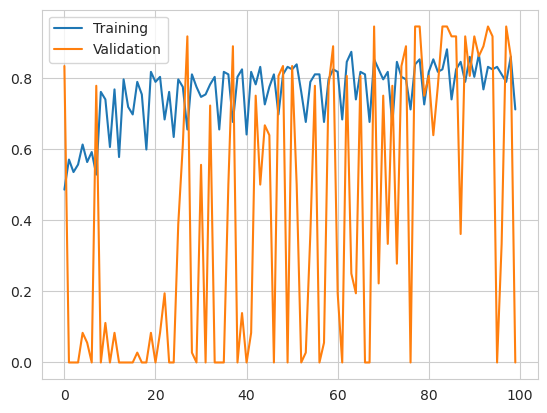

In [12]:
accuracies = history.history['accuracy']
validation_accuracies = history.history['val_accuracy']

plt.plot(accuracies, label='Training')
plt.plot(validation_accuracies, label='Validation')
plt.legend();

[Back to top](#-Index)

### Problem 6

#### A second model



To deal with the above results, one thing to note is the neural networks are sensitive to the scale of the data.  Build a second model named `model_2` below with identical settings to that model above.  Fit this to a scaled version of the `X` data named `X_scaled`, and uncomment the code to plot the results below.  

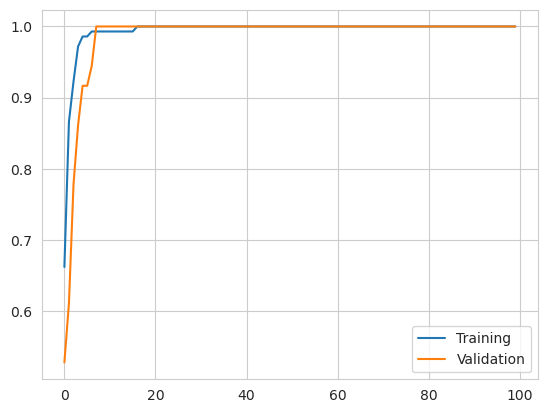

In [13]:

tf.random.set_seed(42)
X_scaled = StandardScaler().fit_transform(X)
model = Sequential([
    Dense(100, activation='relu'),
    Dense(3, activation='softmax')
])
model.compile(
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(X_scaled, y_ohe, epochs=100, validation_split=.2, verbose=0)

accuracies = history.history['accuracy']
validation_accuracies = history.history['val_accuracy']

plt.plot(accuracies, label='Training')
plt.plot(validation_accuracies, label='Validation')
plt.legend();